In [ ]:
# os: getting images data from the directory
import os, shutil
# shutil: used for copying, moving, deleting, archiving(compressing) and Disk Usage
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns   # loading the dataset and for data preprocessing
import cv2
import skimage  # for image processing, segmentation and geometric transformation of images
import skimage.segmentation #segmentation of image

from google.colab import drive
drive.mount('/content/drive')

# Defining the plotting style as inline
# means that the plots are displayed directly within the notebook,
# i.e, output cell below the code, instead of separate windows
%matplotlib inline
plt.style.use('ggplot') # minimalistic look to plots with light grid, for readable view

Mounted at /content/drive


**Segmentation of Images:** partitioning an image into distinct regions, based on specific criteria like color, texture, or intensity.

In [ ]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 128

def get_data(data_dir):
    images = []  # To store the image data
    labels_list = []  # To store the corresponding labels

    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)

        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)
                # Read the image in grayscale mode
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

                # Check if the image is read correctly (sometimes files can be corrupted or unreadable)
                if img_arr is None:
                    print(f"Error reading image: {img_name}")
                    continue

                # Resize the image
                resized_arr = cv2.resize(img_arr, (img_size, img_size))

                # Append the resized image and its label
                images.append(resized_arr)
                labels_list.append(class_num)

            except Exception as e:
                print(f"Error processing image {img_name}: {e}")

    # Convert lists to NumPy arrays
    images = np.array(images)  # Shape: (num_images, img_size, img_size)
    labels_list = np.array(labels_list)  # Shape: (num_images,)

    # Expand dimensions of images to include channels (even if grayscale, we need this for CNNs)
    images = np.expand_dims(images, axis=-1)  # Shape: (num_images, img_size, img_size, 1)

    return images, labels_list

In [ ]:
# Calling the 'get_data' Function to Load Train Images
train_images, train_labels = get_data("/content/drive/MyDrive/data/chest_xray/train")

# Calling the 'get_data' Function to Load Test Images
test_images, test_labels = get_data("/content/drive/MyDrive/data/chest_xray/test")

# Calling the 'get_data' Function to Load Validation Images
val_images, val_labels = get_data("/content/drive/MyDrive/data/chest_xray/val")

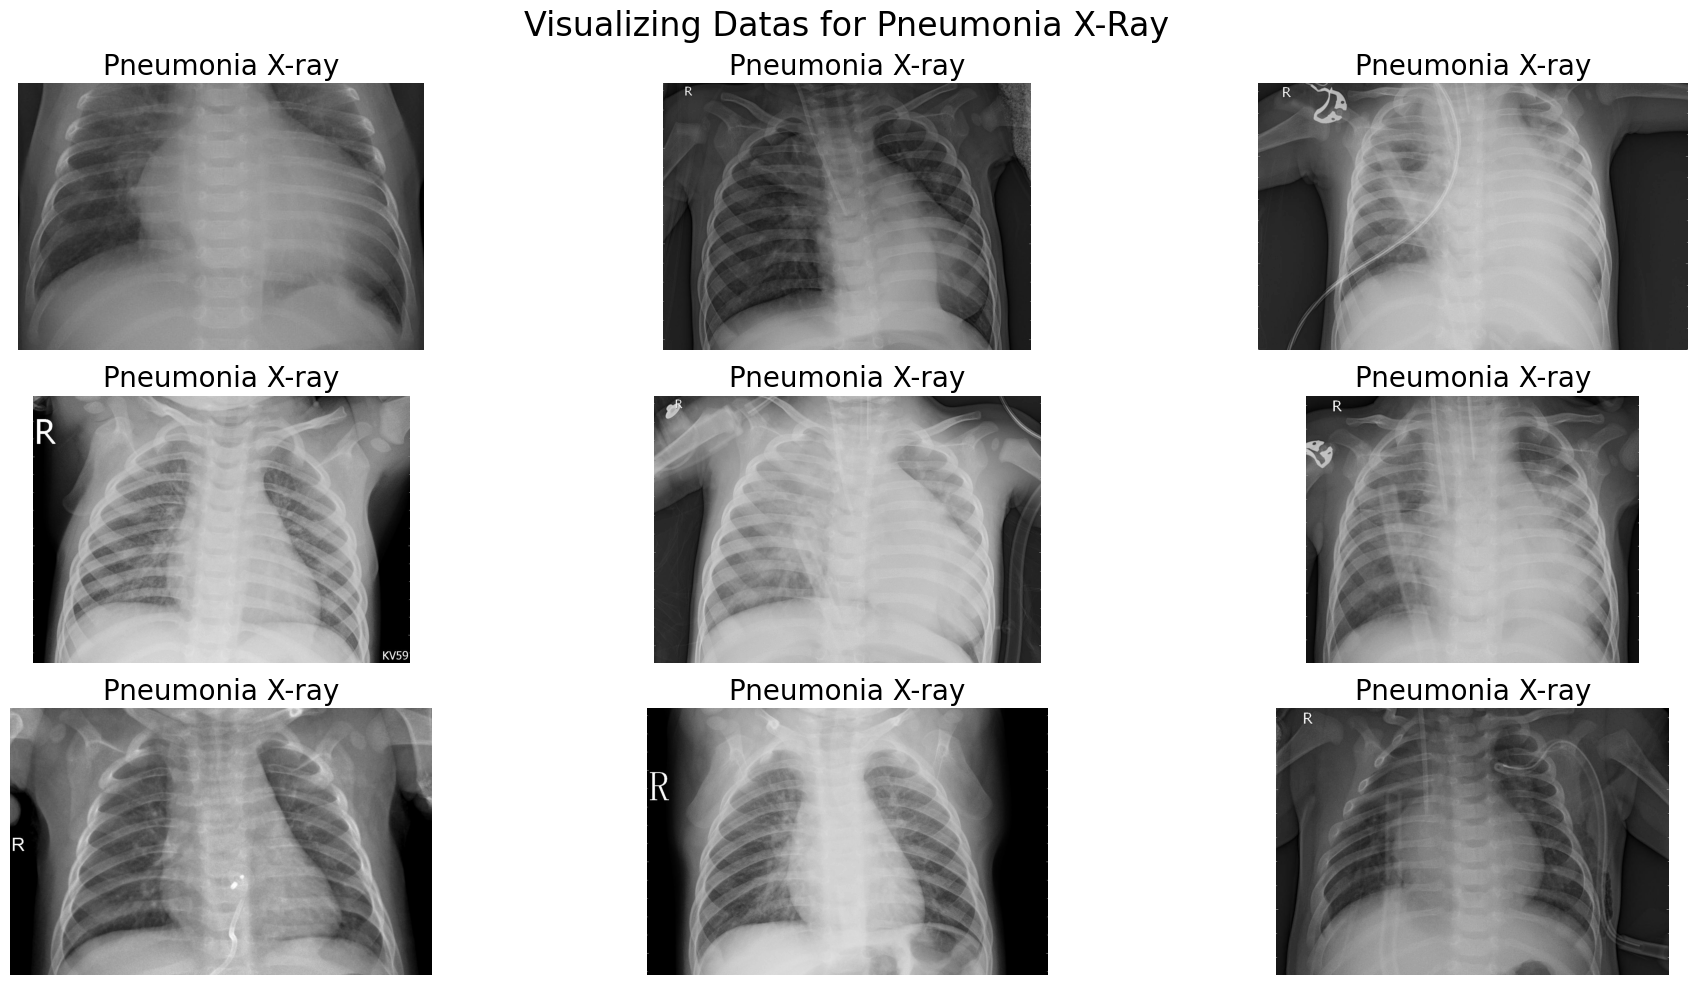

In [ ]:
# List of All the Images for Pneumonia
pneumonia=os.listdir("/content/drive/MyDrive/data/chest_xray/train/PNEUMONIA")

# Directory for the images of the PNEUMONIA
pneumoniaDir="/content/drive/MyDrive/data/chest_xray/train/PNEUMONIA"

# Setting the Image Size to the DataSet
# Size of the total visualizing frame
plt.figure(figsize=(20, 10))

# Looping through the image files and adding them iteratively to subplots
# Plotting 9 images
for i in range(9):
    # Creating a Subplot with 3 rows and 3 columns
    # And, Targeting the i+1 index
    plt.subplot(3, 3, i+1)
    # Reading Image Datasets from the Pneumonia Directory
    imgRead=plt.imread(os.path.join(pneumoniaDir, pneumonia[i]))
    plt.imshow(imgRead, cmap='gray')
    plt.axis("off")
    # Title provided for the each Image samples
    plt.title("Pneumonia X-ray", size=20)
plt.suptitle("Visualizing Datas for Pneumonia X-Ray", size=24)
plt.tight_layout()
plt.show()

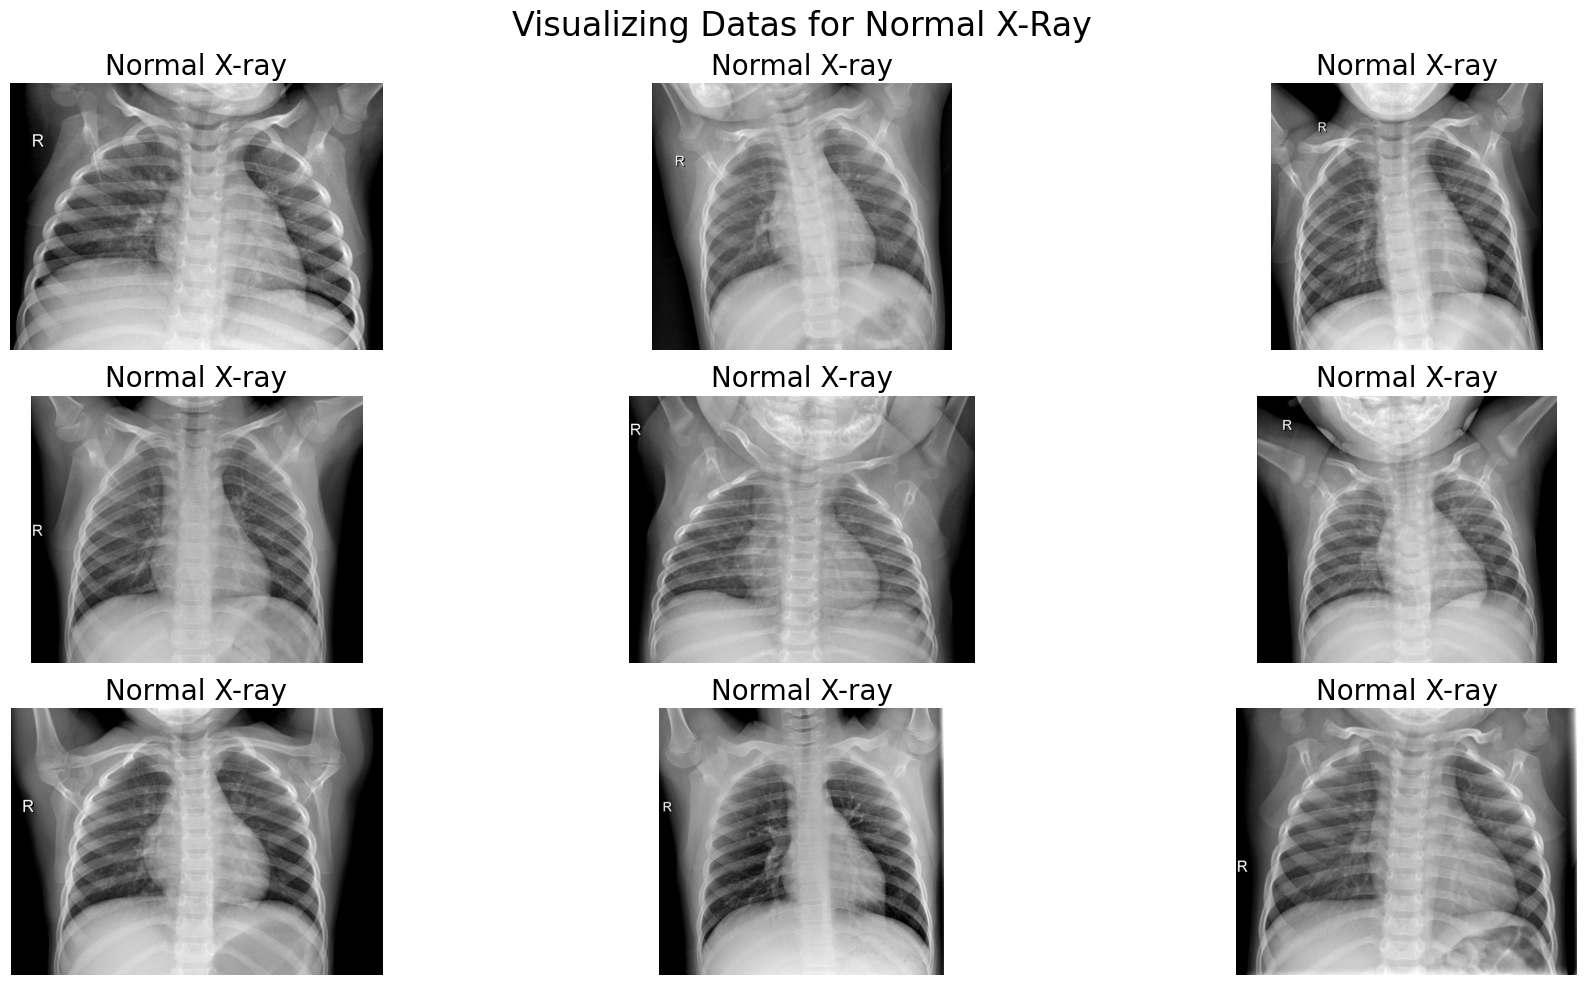

In [ ]:
# List of All the Images for Normal
normal=os.listdir("/content/drive/MyDrive/data/chest_xray/train/NORMAL")

# Directory for the images of the Normal
normalDir="/content/drive/MyDrive/data/chest_xray/train/NORMAL"

# Setting the Image Size to the DataSet
# Size of the total visualizing frame
plt.figure(figsize=(20, 10))

# Looping through the image files and adding them iteratively to subplots
# Plotting 9 images
for i in range(9):
    # Creating a Subplot with 3 rows and 3 columns
    # And, Targeting the i+1 index
    plt.subplot(3, 3, i+1)
    # Reading Image Datasets from the Pneumonia Directory
    imgRead=plt.imread(os.path.join(normalDir, normal[i]))
    plt.imshow(imgRead, cmap='gray')
    plt.axis("off")
    # Title provided for the each Image samples
    plt.title("Normal X-ray", size=20)
plt.suptitle("Visualizing Datas for Normal X-Ray", size=24)
plt.tight_layout()
plt.show()

<ipython-input-7-d3c348dc3263>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=listx, palette=custPalette)


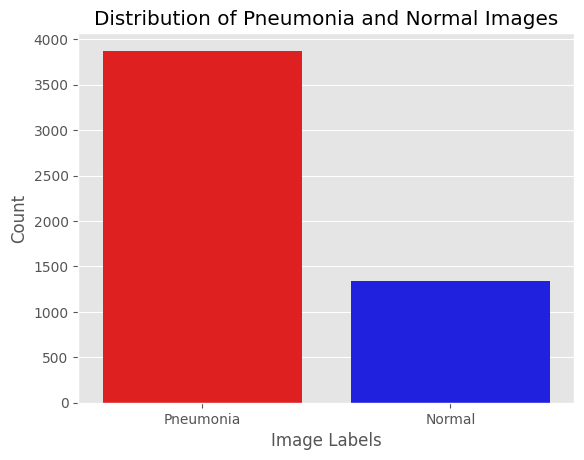

In [ ]:
# Creating an Empty List
listx=[]
for label in train_labels:
    # if it is index 1 is 0 means PNEUMONIA
    if label==0:
        listx.append("Pneumonia")
    else:
        listx.append("Normal")


# Countplot
custPalette={"Pneumonia":"red", "Normal": "blue"}
sns.countplot(x=listx, palette=custPalette)
plt.title("Distribution of Pneumonia and Normal Images")
plt.xlabel("Image Labels")
plt.ylabel("Count")
plt.show()


# **Data Augmentation and Resizing**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D,Dropout
from tensorflow.keras.applications.vgg19 import VGG19
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
train_datagen = ImageDataGenerator(rescale = 1. / 255,
                  horizontal_flip=0.4,
                  vertical_flip=0.4,
                  rotation_range=40,
                  shear_range=0.2,
                  width_shift_range=0.4,
                  height_shift_range=0.4,
                  fill_mode="nearest")
valid_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen = ImageDataGenerator(rescale = 1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory("/content/drive/MyDrive/data/chest_xray/train",
                                                    batch_size = 32,
                                                    target_size=(128,128),
                                                    class_mode = 'categorical',
                                                    shuffle=True,
                                                    seed = 42,
                                                    color_mode = 'rgb')
valid_generator = valid_datagen.flow_from_directory("/content/drive/MyDrive/data/chest_xray/val",
                                                    batch_size = 32,
                                                    target_size=(128,128),
                                                    class_mode = 'categorical',
                                                    shuffle=True,
                                                    seed = 42,
                                                    color_mode = 'rgb')

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [ ]:
class_labels = train_generator.class_indices
class_labels

{'NORMAL': 0, 'PNEUMONIA': 1}

In [ ]:
class_name = {value:key for (key, value) in class_labels.items()}
class_name

{0: 'NORMAL', 1: 'PNEUMONIA'}

## **VGG-19 CNN Architecture**

In [ ]:
base_model = VGG19(input_shape = (128,128,3),
                     include_top = False,
                     weights = 'imagenet')
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
flat = Flatten()(x)


class_1 = Dense(4608, activation = 'relu')(flat)
dropout = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation = 'relu')(dropout)
output = Dense(2, activation = 'softmax')(class_2)

model_01 = Model(base_model.inputs, output)
model_01.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 63,089,602 (240.67 MB)

 Trainable params: 43,065,218 (164.28 MB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
filepath = "model.keras"
es = EarlyStopping(monitor="val_loss", verbose=1, mode="min", patience=4)
cp=ModelCheckpoint(filepath, monitor="val_loss", save_best_only=True, save_weights_only=False,mode="auto", save_freq="epoch")
lrr = ReduceLROnPlateau(monitor="val_accuracy", patience=3, verbose=1, factor=0.5, min_lr=0.0001)

sgd = SGD(learning_rate=0.0001, decay = 1e-6, momentum=0.9, nesterov = True)

model_01.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [ ]:
history_01 = model_01.fit(
    train_generator,
    steps_per_epoch=2600,  #50
    epochs=5, #1
    callbacks=[es, cp, lrr],
    validation_data=valid_generator)

Epoch 1/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 86s 32ms/step - accuracy: 0.8766 - loss: 0.2762 - val_accuracy: 0.6250 - val_loss: 0.8149 - learning_rate: 1.0000e-04
Epoch 2/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 142s 32ms/step - accuracy: 0.8741 - loss: 0.2821 - val_accuracy: 0.6250 - val_loss: 0.8723 - learning_rate: 1.0000e-04
Epoch 3/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 88s 32ms/step - accuracy: 0.8799 - loss: 0.2739 - val_accuracy: 0.6875 - val_loss: 0.6564 - learning_rate: 1.0000e-04
Epoch 4/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 85s 31ms/step - accuracy: 0.8804 - loss: 0.2763 - val_accuracy: 0.6875 - val_loss: 0.7654 - learning_rate: 1.0000e-04
Epoch 4: early stopping


In [ ]:
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")
model_01.save(filepath = "model_weights/vgg19_model_01.h5", overwrite=True)

In [ ]:
test_generator = test_datagen.flow_from_directory("/content/drive/MyDrive/data/chest_xray/test",
                                 batch_size = 32,
                                 target_size=(128,128),
                                 class_mode = 'categorical',
                                 shuffle=True,
                                 seed = 42,
                                 color_mode = 'rgb')

Found 624 images belonging to 2 classes.


In [ ]:
model_01.load_weights("model_weights/vgg19_model_01.h5")

vgg_val_eval_01 = model_01.evaluate(valid_generator)
vgg_test_eval_01 = model_01.evaluate(test_generator)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.6875 - loss: 0.7654
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 312ms/step - accuracy: 0.7660 - loss: 0.4970


In [ ]:
print(f"Validation Loss: {vgg_val_eval_01[0]}")
print(f"Validation Accuarcy: {vgg_val_eval_01[1]}")
print(f"Test Loss: {vgg_test_eval_01[0]}")
print(f"Test Accuarcy: {vgg_test_eval_01[1]}")

Validation Loss: 0.7653924226760864
Validation Accuarcy: 0.6875
Test Loss: 0.4808034598827362
Test Accuarcy: 0.7820512652397156


# **Incremental Unfreezing and Fine Tuning**

In [ ]:
base_model = VGG19(include_top=False, input_shape=(128,128,3))
base_model_layer_names = [layer.name for layer in base_model.layers]

x = base_model.output
flat = Flatten()(x)


class_1 = Dense(4608, activation = 'relu')(flat)
dropout = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation = 'relu')(dropout)
output = Dense(2, activation = 'softmax')(class_2)

model_02 = Model(base_model.inputs, output)
model_02.load_weights("model_weights/vgg19_model_01.h5")

set_trainable = False
for layer in base_model.layers:
    if layer.name in [ 'block5_conv3','block5_conv4']:
        set_trainable=True
    if set_trainable:
        set_trainable=True
    else:
        set_trainable=False
print(model_02.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 63,089,602 (240.67 MB)

 Trainable params: 63,089,602 (240.67 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
base_model_layer_names

['input_layer_2',
 'block1_conv1',
 'block1_conv2',
 'block1_pool',
 'block2_conv1',
 'block2_conv2',
 'block2_pool',
 'block3_conv1',
 'block3_conv2',
 'block3_conv3',
 'block3_conv4',
 'block3_pool',
 'block4_conv1',
 'block4_conv2',
 'block4_conv3',
 'block4_conv4',
 'block4_pool',
 'block5_conv1',
 'block5_conv2',
 'block5_conv3',
 'block5_conv4',
 'block5_pool']

In [ ]:
sgd = SGD(learning_rate=0.0001, decay = 1e-6, momentum=0.9, nesterov = True)

model_02.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=['accuracy'])

In [ ]:
history_02 = model_02.fit(train_generator,
            steps_per_epoch=2600, #10
            epochs=5, #1
            callbacks=[es, cp, lrr],
            validation_data=valid_generator)

Epoch 1/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 99s 35ms/step - accuracy: 0.8987 - loss: 0.2322 - val_accuracy: 0.6875 - val_loss: 0.5239 - learning_rate: 1.0000e-04
Epoch 2/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 142s 36ms/step - accuracy: 0.9308 - loss: 0.1777 - val_accuracy: 0.6875 - val_loss: 0.3667 - learning_rate: 1.0000e-04
Epoch 3/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 99s 36ms/step - accuracy: 0.9390 - loss: 0.1507 - val_accuracy: 0.8750 - val_loss: 0.2381 - learning_rate: 1.0000e-04
Epoch 4/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 143s 37ms/step - accuracy: 0.9455 - loss: 0.1411 - val_accuracy: 0.9375 - val_loss: 0.1533 - learning_rate: 1.0000e-04
Epoch 5/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 95s 35ms/step - accuracy: 0.9491 - loss: 0.1324 - val_accuracy: 0.6875 - val_loss: 0.5257 - learning_rate: 1.0000e-04


In [ ]:
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")
model_02.save(filepath = "model_weights/vgg19_model_02.h5", overwrite=True)

In [ ]:
model_02.load_weights("model_weights/vgg19_model_02.h5")

vgg_val_eval_02 = model_02.evaluate(valid_generator)
vgg_test_eval_02 = model_02.evaluate(test_generator)

print(f"Validation Loss: {vgg_val_eval_02[0]}")
print(f"Validation Accuarcy: {vgg_val_eval_02[1]}")
print(f"Test Loss: {vgg_test_eval_02[0]}")
print(f"Test Accuarcy: {vgg_test_eval_02[1]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.6875 - loss: 0.5257
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 307ms/step - accuracy: 0.8479 - loss: 0.6041
Validation Loss: 0.5256851315498352
Validation Accuarcy: 0.6875
Test Loss: 0.5556564331054688
Test Accuarcy: 0.8637820482254028


# **Unfreezing and fine tuning the entire network**

In [ ]:
base_model = VGG19(include_top=False, input_shape=(128,128,3))

x = base_model.output
flat = Flatten()(x)

class_1 = Dense(4608, activation = 'relu')(flat)
dropout = Dropout(0.2)(class_1)
class_2 = Dense(1152, activation = 'relu')(dropout)
output = Dense(2, activation = 'softmax')(class_2)

model_03 = Model(base_model.inputs, output)
model_03.load_weights("model_weights/vgg19_model_01.h5")

print(model_03.summary())

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv4 (Conv2D)                │ (None, 32, 32, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv4 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv4 (Conv2D)                │ (None, 8, 8, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 63,089,602 (240.67 MB)

 Trainable params: 63,089,602 (240.67 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
sgd = SGD(learning_rate=0.0001, decay = 1e-6, momentum=0.9, nesterov = True)
model_03.compile(loss="categorical_crossentropy", optimizer=sgd, metrics=['accuracy'])

In [ ]:
history_03 = model_02.fit(train_generator,
            steps_per_epoch=2600,
            epochs=5, #1
            callbacks=[es, cp, lrr],
            validation_data=valid_generator)

Epoch 1/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 107s 38ms/step - accuracy: 0.9600 - loss: 0.0988 - val_accuracy: 1.0000 - val_loss: 0.1252 - learning_rate: 1.0000e-04
Epoch 2/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 134s 37ms/step - accuracy: 0.9611 - loss: 0.0999 - val_accuracy: 1.0000 - val_loss: 0.0999 - learning_rate: 1.0000e-04
Epoch 3/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 137s 35ms/step - accuracy: 0.9661 - loss: 0.0938 - val_accuracy: 1.0000 - val_loss: 0.1160 - learning_rate: 1.0000e-04
Epoch 4/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 95s 35ms/step - accuracy: 0.9653 - loss: 0.0957 - val_accuracy: 1.0000 - val_loss: 0.1267 - learning_rate: 1.0000e-04
Epoch 5/5
2600/2600 ━━━━━━━━━━━━━━━━━━━━ 141s 35ms/step - accuracy: 0.9683 - loss: 0.0899 - val_accuracy: 0.9375 - val_loss: 0.1606 - learning_rate: 1.0000e-04


In [ ]:
if not os.path.isdir('model_weights/'):
    os.mkdir("model_weights/")
model_02.save(filepath = "model_weights/vgg_unfrozen.h5", overwrite=True)